In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [8]:
adata_vis = sc.read_h5ad('../../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad')
pred_df = pd.read_csv('./mydestvi_predicted_proportions_mmdAndL1.csv')

In [9]:
# 都转成字符串类型
pred_df.index = pred_df.index.astype(str)

发现 'true_proportion'，开始计算与预测值的相关性。

预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):
pericyte                                           0.906400
immune cell                                        0.726653
kidney collecting duct epithelial cell             0.815549
endothelial cell                                   0.739160
podocyte                                           0.859391
kidney loop of Henle epithelial cell               0.959486
kidney distal convoluted tubule epithelial cell    0.787052
epithelial cell of proximal tubule                 0.975713
dtype: float64

平均相关系数:  0.8461755552026913
相关性柱状图已保存为 'destvi_validation_correlation.png'


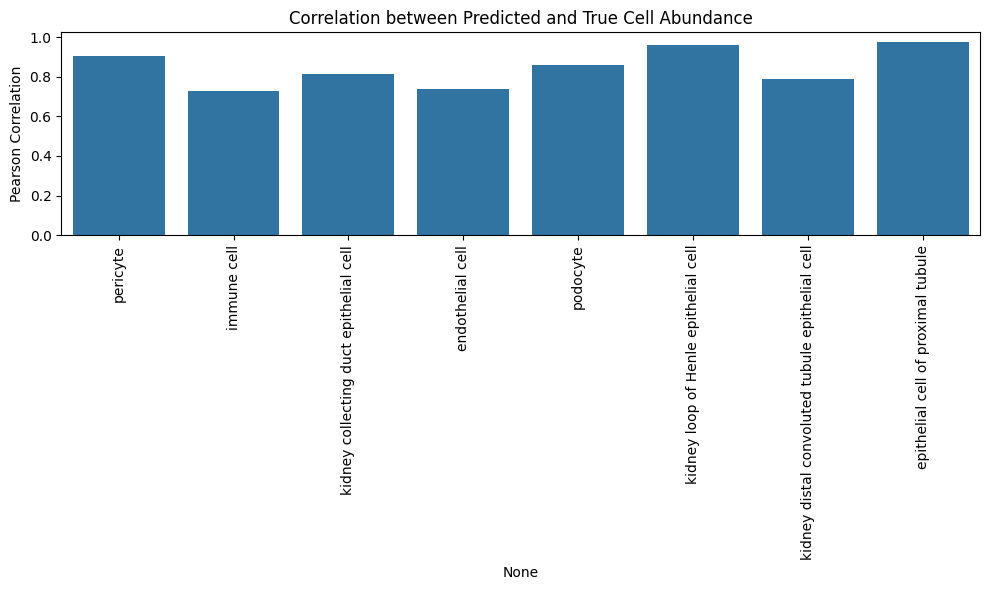

In [10]:
# 可选验证：与 true_proportion 的相关性
if 'true_proportion' in adata_vis.obsm:
    print("发现 'true_proportion'，开始计算与预测值的相关性。")
    true_df = pd.DataFrame(adata_vis.obsm['true_proportion'],
                           index=adata_vis.obs_names,
                           columns=adata_vis.uns['cell_types'])
    common_cell_types = list(set(pred_df.columns) & set(true_df.columns))
    if not common_cell_types:
        print("警告：预测的细胞类型和真实的细胞类型没有交集，无法进行相关性比较！")
    else:
        pred_c = pred_df[common_cell_types]
        true_c = true_df[common_cell_types]
        correlations = pred_c.corrwith(true_c, axis=0)
        print("\n预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):")
        print(correlations)
        print("\n平均相关系数: ", correlations.mean())
        plt.figure(figsize=(10, 6))
        sns.barplot(x=correlations.index, y=correlations.values)
        plt.xticks(rotation=90)
        plt.ylabel("Pearson Correlation")
        plt.title("Correlation between Predicted and True Cell Abundance")
        plt.tight_layout()
        plt.savefig("destvi_validation_correlation.png", dpi=300)
        print("相关性柱状图已保存为 'destvi_validation_correlation.png'")
else:
    print("在空间数据中未找到 'true_proportion'，跳过验证步骤。")


In [11]:
    # 计算每个Spot的RMSE
import numpy as np
rmse_per_spot = np.sqrt(((pred_c - true_c) ** 2).mean(axis=1))
print("\n每个Spot的RMSE：")
print(rmse_per_spot)
print("均方根误差均值：", np.mean(rmse_per_spot))


每个Spot的RMSE：
0       0.044771
1       0.053502
2       0.064228
3       0.100615
4       0.095179
          ...   
1515    0.053516
1516    0.001411
1517    0.017599
1518    0.029444
1519    0.105883
Length: 1520, dtype: float64
均方根误差均值： 0.06070163347697673


In [12]:
from scipy.spatial.distance import jensenshannon

# 归一化，确保每个spot的比例和为1
pred_norm = pred_c.div(pred_c.sum(axis=1), axis=0)
true_norm = true_c.div(true_c.sum(axis=1), axis=0)

jsd_list = []
for i in range(pred_norm.shape[0]):
    p = pred_norm.iloc[i].values
    q = true_norm.iloc[i].values
    jsd = jensenshannon(p, q, base=2)  # base=2得到0~1之间的JSD
    jsd_list.append(jsd)

jsd_per_spot = pd.Series(jsd_list, index=pred_norm.index)
print("\n每个Spot的JSD：")
print(jsd_per_spot)
print("JSD均值：", jsd_per_spot.mean())



每个Spot的JSD：
0       0.219130
1       0.256421
2       0.265394
3       0.313845
4       0.271799
          ...   
1515    0.191370
1516    0.040840
1517    0.140309
1518    0.181787
1519    0.371124
Length: 1520, dtype: float64
JSD均值： 0.26292607166153176
